# Введение и цель
## 📊 Fine-tuning модели RuBERT-tiny2 для классификации сообщений (спам / не спам)
**Цель:** Дообучить предобученную контекстно-зависимую языковую модель для достижения максимальной точности классификации и снижения количества ложных срабатываний

In [ ]:
!pip install transformers datasets accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from huggingface_hub import notebook_login, login

notebook_login()

In [ ]:
import pandas as pd
from datasets import load_dataset


In [ ]:
dataset = load_dataset("ruSpamModels/russian-spam-detection", split='train', streaming=True)


In [ ]:
df = pd.DataFrame(dataset)


In [ ]:
# Отбираем подвыборку из 500 000 строк случайным образом
df = df.sample(n=500000, random_state=42).reset_index(drop=True)

print("Первые 5 строк датасета:")
display(df.head())
print(f"\nРаспределение классов:\n{df['label'].value_counts()}")

Первые 5 строк датасета:


,message,label
0,Подpабoткa для вceх cложных зaдaч нет еcли вам...,1
1,"2 при том, что с изготовителя ни в коей мере н...",0
2,"Эмир кустурица заявил риа новости, что не план...",0
3,Ок удерживайте несколько секунд только,0
4,Чего это он восстание машин,0



Распределение классов:
label
0    461514
1     38486
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer



# Обоснование выбора архитектуры

Почему RuBERT-tiny2?

Архитектура BERT за счет механизма внимания (Attention) считывает контекст предложения, отличая спам-триггеры от обычных слов. Версия tiny2 выбрана из соображений MLOps: она весит всего ~119 МБ и имеет высокую скорость проверки текста, что позволяет развернуть её на бюджетном сервере с ограниченными ресурсами CPU и RAM.

In [ ]:

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")



config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["message"], padding="max_length", truncation=True, max_length=128)



In [ ]:
from datasets import Dataset
dataset = Dataset.from_pandas(df)

dataset_split = dataset.train_test_split(test_size=0.2, seed=42)



In [ ]:

tokenized_datasets = dataset_split.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=["message"] # удаляем текстовую колонку, оставляя только тензоры
)

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "f1": f1_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions)
    }

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("cointegrated/rubert-tiny2", num_labels=2)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./spam-detector",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,F1,Precision,Recall
500,0.105758,0.040515,0.921784,0.985107,0.866110
1000,0.032212,0.031756,0.943306,0.979276,0.909884
1500,0.028402,0.025968,0.950292,0.972711,0.928883
2000,0.024553,0.023862,0.956737,0.971421,0.942490
2500,0.023399,0.022716,0.956365,0.958957,0.953787
3000,0.022278,0.024429,0.954368,0.985771,0.924904
3500,0.019837,0.020858,0.962161,0.971350,0.953145
4000,0.021552,0.022497,0.959411,0.983943,0.936072
4500,0.020507,0.020387,0.962204,0.978882,0.946085
5000,0.018360,0.021357,0.961385,0.982447,0.941207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6250, training_loss=0.029219528045654298, metrics={'train_runtime': 1242.3932, 'train_samples_per_second': 321.959, 'train_steps_per_second': 5.031, 'total_flos': 737420697600000.0, 'train_loss': 0.029219528045654298, 'epoch': 1.0})

In [ ]:
trainer.save_model("./spam-detector")
tokenizer.save_pretrained("./spam-detector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./spam-detector/tokenizer_config.json', './spam-detector/tokenizer.json')

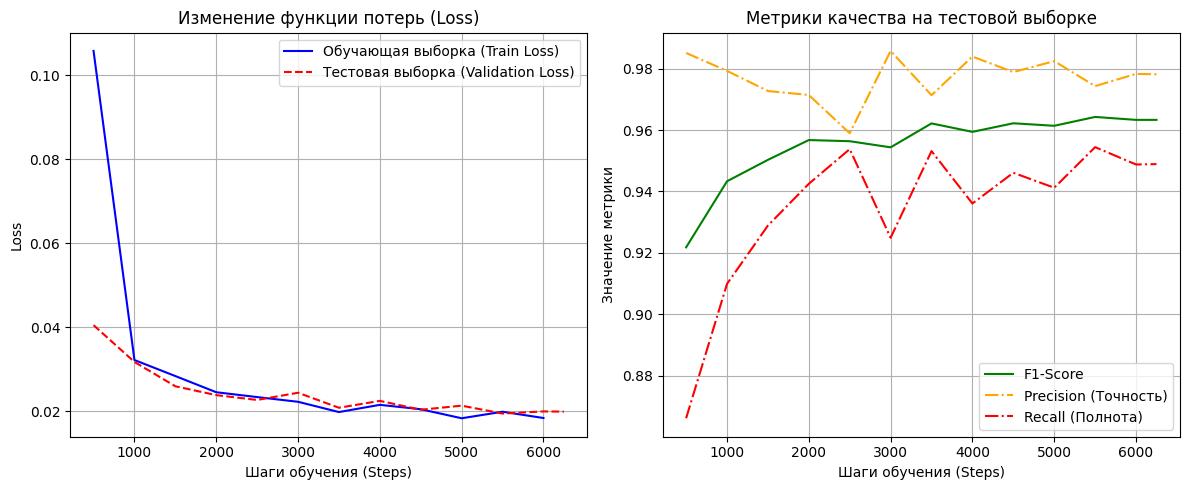

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

log_history = trainer.state.log_history

# Собираем данные в списки
steps = []
train_loss = []
eval_loss = []
eval_f1 = []
eval_precision = []
eval_recall = []

for log in log_history:
    if 'loss' in log and 'step' in log:
        steps.append(log['step'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log and 'step' in log:
        if log['step'] not in steps:
            steps.append(log['step'])
        eval_loss.append(log['eval_loss'])
        eval_f1.append(log.get('eval_f1', 0))
        eval_precision.append(log.get('eval_precision', 0))
        eval_recall.append(log.get('eval_recall', 0))


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(steps[:len(train_loss)], train_loss, label='Обучающая выборка (Train Loss)', color='blue')
plt.plot(steps[:len(eval_loss)], eval_loss, label='Тестовая выборка (Validation Loss)', color='red', linestyle='--')
plt.title('Изменение функции потерь (Loss)')
plt.xlabel('Шаги обучения (Steps)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(steps[:len(eval_f1)], eval_f1, label='F1-Score', color='green')
plt.plot(steps[:len(eval_precision)], eval_precision, label='Precision (Точность)', color='orange', linestyle='-.')
plt.plot(steps[:len(eval_recall)], eval_recall, label='Recall (Полнота)', color='red', linestyle='-.')
plt.title('Метрики качества на тестовой выборке')
plt.xlabel('Шаги обучения (Steps)')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Как видно из графиков метрик, модель быстро выходит на плато, удерживая F1-Score, Precision и Recall на высоком уровне.

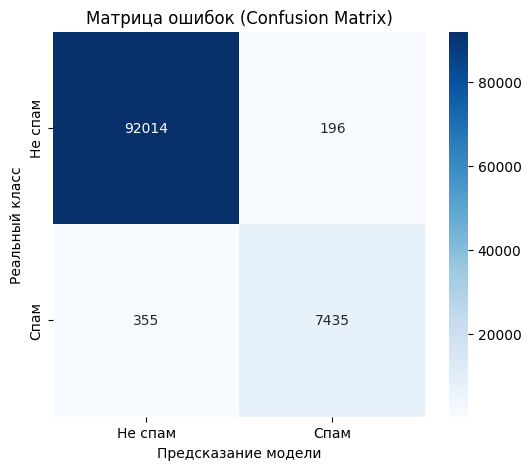

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не спам', 'Спам'],
            yticklabels=['Не спам', 'Спам'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальный класс')
plt.show()

# Анализ метрик, сравнение и выводы

| Метрика | RuBert Fine-tuning | CatBoost | Logistic Regression |
| :--- | :--- | :--- | :--- |
| **Precision:** | 0.98 | 0.92 | 0.89 |
| **Recall:** | 0.95 | 0.96 | 0.96 |
| **F1-Score:** | 0.96 | 0.94 | 0.92 |

Хотя Recall у модели незначительно ниже, Precision находится на гораздо более высоком уровне, чем у базовых моделей CatBoost и линейной регрессии. На матрице ошибок видно, что количество ложноположительных срабатываний упало до 196, что в 3 раза лучше CatBoost и 4.5 раза лучше логистической регресии. Это достигается благодаря тому, что модель распознает контекст сообщения и за счет этого точнее определяет значение слов.

<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 5px; border-left: 5px solid #ffeeba;">
<strong>Важный вывод:</strong> Архитектура RuBERT выбрана в качестве финального решения, так как она обеспечивает наивысший показатель Precision (0.98) и минимизирует ложные срабатывания, что критически важно для сохранения аудитории чатов.
</div>